In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

In [ ]:
num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [ ]:
state_size = env.observation_space.n
action_size = env.action_space.n

Q = np.zeros((state_size, action_size))

In [ ]:
def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [ ]:
episode_rewards = []

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    for step in range(max_steps_per_episode):
        action = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        best_next_action = np.max(Q[next_state])
        Q[state, action] = Q[state, action] + alpha * (reward + gamma * best_next_action - Q[state, action])
        state = next_state
        total_reward += reward
        if terminated or truncated:
            break
    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [ ]:
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

In [ ]:
def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [ ]:
print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])

print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.941 0.951 0.951 0.941]
 [0.941 0.    0.961 0.951]
 [0.951 0.97  0.951 0.961]
 [0.961 0.    0.95  0.95 ]
 [0.944 0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.961]
 [0.    0.    0.    0.   ]
 [0.912 0.    0.97  0.904]
 [0.957 0.977 0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.936 0.99  0.933]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.951


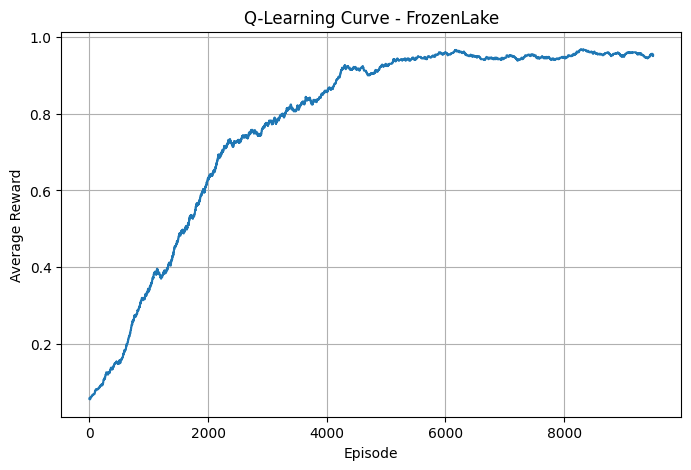

In [ ]:
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()